# Training the model

### Setting up the device

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_PATH = Path("data/processed/splits.npz")
MODEL_PATH = Path("robot_autoencoder.pth")

Using device: cuda


### Load processed data
Loading `splits.npz` from notebook: `01_data_preparation.ipynb`

In [6]:
# load data
data = np.load(DATA_PATH)

# convert to PyTorch Tensors (and ensure float32)
X_train = torch.tensor(data['X_train'], dtype=torch.float32)
X_val   = torch.tensor(data['X_val'], dtype=torch.float32)

# create DataLoaders
# batch size = 128 for good balance of memory and speed
train_loader = DataLoader(TensorDataset(X_train), batch_size=128, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val), batch_size=128)

print(f"Loaded {X_train.shape[0]} training samples and {X_val.shape[0]} validation samples.")

Loaded 204854 training samples and 43865 validation samples.


### MLP Autoencoder Architecture
Encoder: compressing the 300 numbers down to 32

Decoder: reconstruct the 300 numbers back to the original

In [7]:
class RobotAutoencoder(nn.Module):
    def __init__(self, input_dim=300):
        super(RobotAutoencoder, self).__init__()
        
        # Ecoder: compressing the 300 numbers down to 32
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32), # bottleneck is here
            nn.ReLU()
        )
        
        # Decoder: reconstruct the 300 numbers back to the original
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            # dropout layer if it overfits
            nn.ReLU(),
            nn.Linear(128, input_dim) 
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = RobotAutoencoder().to(device)
print(model)

RobotAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=300, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=300, bias=True)
  )
)


### Loss Function and Optimiser
Setting loss function and optimiser

Using **MSELoss** to minimise the difference between the original 300 numbers and the reconstructed 300 numbers

In [8]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training Loop
The learning process (loss values should drop)

In [ ]:
epochs = 20
history = {'train_loss': [], 'val_loss': []}

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    train_running_loss = 0.0
    
    for batch in train_loader:
        inputs = batch[0].to(device)
        
        # Reset gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        train_running_loss += loss.item()
    
    # Validation
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            inputs = batch[0].to(device)
            outputs = model(inputs)
            v_loss = criterion(outputs, inputs)
            val_running_loss += v_loss.item()
            
    # Save stats
    epoch_train_loss = train_running_loss / len(train_loader)
    epoch_val_loss = val_running_loss / len(val_loader)
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

# Save trained weights
torch.save(model.state_dict(), MODEL_PATH)
print(f"Finished! Model saved to {MODEL_PATH}")

Starting Training...
Epoch [1/20] - Train Loss: 0.118957 | Val Loss: 0.077464
Epoch [2/20] - Train Loss: 0.071826 | Val Loss: 0.068038
Epoch [3/20] - Train Loss: 0.064561 | Val Loss: 0.063242
Epoch [4/20] - Train Loss: 0.061665 | Val Loss: 0.061036
Epoch [5/20] - Train Loss: 0.060215 | Val Loss: 0.059837
Epoch [6/20] - Train Loss: 0.059095 | Val Loss: 0.058819
Epoch [7/20] - Train Loss: 0.058166 | Val Loss: 0.058280
Epoch [8/20] - Train Loss: 0.057242 | Val Loss: 0.056996
Epoch [9/20] - Train Loss: 0.056561 | Val Loss: 0.056797
Epoch [10/20] - Train Loss: 0.056035 | Val Loss: 0.056092
Epoch [11/20] - Train Loss: 0.055684 | Val Loss: 0.055827
Epoch [12/20] - Train Loss: 0.055406 | Val Loss: 0.055363
Epoch [13/20] - Train Loss: 0.055119 | Val Loss: 0.055410
Epoch [14/20] - Train Loss: 0.054823 | Val Loss: 0.055068
Epoch [15/20] - Train Loss: 0.054597 | Val Loss: 0.054599
Epoch [16/20] - Train Loss: 0.054295 | Val Loss: 0.054539
Epoch [17/20] - Train Loss: 0.053983 | Val Loss: 0.054532
Ep

In [ ]:
'''
For quick test loading without retraining (or for use in a new notebook)

run the following lines:
'''

# # recreate the structure
# test_model = RobotAutoencoder().to(device)

# # load weights
# test_model.load_state_dict(torch.load("robot_autoencoder.pth"))

# # set to evaluation mode
# test_model.eval()

# print("Model loaded and ready for testing.")

### Visualising results

This is the learning curve

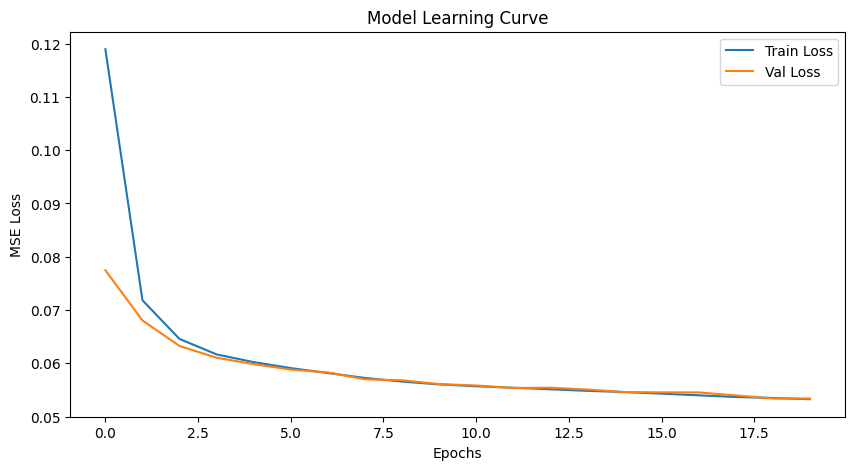

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Model Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

### Analysing the graph

- **Good convergence:** both curves trend downards and almost flattens out near 0.053, model learned the normal patterns
- **No overfitting found:** blue and orange lines are touching, good generalisation
- **Stable:** no random spikes spotted

Moving on to `03_inference.ipynb` to test the model for anomalies